# Common topics
- The Aim of this notebook is to create topic clusters starting from different models to determine the common topics.
- The similarity metric used in this notebook is topic closeness.
- See the original paper at https://arxiv.org/abs/2412.18376

## Loading libraries

In [6]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [7]:
import pipeline.src.python.config as cfg
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)
import networkx as nx
import leidenalg
import igraph as ig
from collections import defaultdict
import torch
from sentence_transformers import SentenceTransformer

/home/banfi/.uve/cuda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading models

In [3]:
embedding_model = SentenceTransformer(
    cfg.EMBEDDING_MODEL,            
    device="cuda",                  
    model_kwargs={"torch_dtype": torch.bfloat16},  
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 27.64it/s]


In [ ]:
MAGAZINE_1 = 'scopus'
cfg_dict_1 = cfg.MAGAZINE_CONFIG[MAGAZINE_1]

In [5]:
MAGAZINE_2 = 'the_guardian'
cfg_dict_2 = cfg.MAGAZINE_CONFIG[MAGAZINE_2]

In [6]:
MAGAZINE_3 = 'science_news'
cfg_dict_3 = cfg.MAGAZINE_CONFIG[MAGAZINE_3]

In [7]:
from bertopic import BERTopic

model_path = cfg_dict_1['REFERENCE_MODEL']
model_1 = BERTopic.load(model_path, 
                      embedding_model=embedding_model
                      )

In [8]:
model_path_2 = cfg_dict_2['REFERENCE_MODEL']

model_2 = BERTopic.load(model_path_2,
                        embedding_model
                        )


In [9]:
model_path_3 = cfg_dict_3['REFERENCE_MODEL']

model_3 = BERTopic.load(model_path_3,
                        embedding_model
                        )


## Loading data

In [ ]:
data = np.load(cfg_dict_1['OUTPUT_PATH'],allow_pickle=True) 

ids = data['id']
texts = data['text'] 
embeddings = data['embedding'] 

In [ ]:
data_2 = np.load(cfg_dict_2['OUTPUT_PATH'],allow_pickle=True) 

ids_2 = data_2['id']
texts_2 = data_2['text'] 
embeddings_2 = data_2['embedding'] 

In [ ]:
data_3 = np.load(cfg_dict_3['OUTPUT_PATH'],allow_pickle=True) 

ids_3 = data_3['id']
texts_3 = data_3['text'] 
embeddings_3 = data_3['embedding'] 

## BTM Metrics evaluation - Model 1 vs Model 2

### First side evalutation - Model 1 -> Model 2

In [13]:
from pipeline.src.python.btm import BTM

models_metrics_1_vs_2 = BTM(model_1=model_1,
                            model_2=model_2,
                            ids_1=ids,
                            texts_1=texts,
                            embeddings_1=embeddings,
                            texts_2=texts_2,
                            embeddings_2=embeddings_2,
                            model_1_name=MAGAZINE_1.title(),
                            model_2_name=MAGAZINE_2.title())

2026-05-06 17:11:51,733 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


2026-05-06 17:11:52,845 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.26085150957107545
84163/155749 are classified as outlier due to their threshold values


In [14]:
models_metrics_1_vs_2.evaluate_metrics()

In [15]:
models_metrics_1_vs_2.print_weighted_corpus_metrics()

Evaluation: Scopus -> The_Guardian
Corpus Closeness: 0.4542244251969515
Evaluation: Scopus -> The_Guardian
Corpus Uniqueness: 0.5457755748030485
Evaluation: Scopus -> The_Guardian
Corpus Alignment: 0.28597294364650816


In [16]:
model_1_vs_model_2_closeness = models_metrics_1_vs_2.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

### Second side evaluation - Model 2 -> Model 1

In [17]:
inverse_models_metrics_2_vs_1 = BTM(model_1=model_2,
                                    model_2=model_1,
                                    ids_1=ids_2,
                                    texts_1=texts_2,
                                    embeddings_1=embeddings_2,
                                    texts_2=texts,
                                    embeddings_2=embeddings,
                                    model_1_name=MAGAZINE_2.title(),model_2_name=MAGAZINE_1.title())

2026-05-06 17:12:12,995 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-05-06 17:13:03,751 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.24699661791324615
7468/24837 are classified as outlier due to their threshold values


In [18]:
inverse_models_metrics_2_vs_1.evaluate_metrics()

In [19]:
model_2_vs_model_1_closeness = inverse_models_metrics_2_vs_1.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

## BTM Metrics evaluation - Model 1 vs Model 3

### First side evaluation - Model 1 -> Model 3

In [ ]:
models_metrics_1_vs_3 = BTM(model_1=model_1,
                            model_2=model_3,
                            ids_1=ids,
                            texts_1=texts,
                            embeddings_1=embeddings,
                            texts_2=texts_3,
                            embeddings_2=embeddings_3,
                            model_1_name=MAGAZINE_1.title(),
                            model_2_name=MAGAZINE_3.title())

2026-05-06 17:13:07,843 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-05-06 17:13:07,870 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.27406691402196887
97254/155749 are classified as outlier due to their threshold values


In [21]:
models_metrics_1_vs_3.evaluate_metrics()

In [22]:
model_1_vs_model_3_closeness = models_metrics_1_vs_3.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

### Second side evaluation - Model 3 -> Model 1

In [23]:
inverse_models_metrics_3_vs_1 = BTM(model_1=model_3,
                                    model_2=model_1,
                                    ids_1=ids_3,
                                    texts_1=texts_3,
                                    embeddings_1=embeddings_3,
                                    texts_2=texts,
                                    embeddings_2=embeddings,
                                    model_1_name=MAGAZINE_3.title(),
                                    model_2_name=MAGAZINE_1.title())

2026-05-06 17:13:30,137 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-05-06 17:13:55,263 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.24699661791324615
70/868 are classified as outlier due to their threshold values


In [24]:
inverse_models_metrics_3_vs_1.evaluate_metrics()

In [25]:
model_3_vs_model_1_closeness = inverse_models_metrics_3_vs_1.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

## BTM Metrics evaluation - Model 2 vs Model 3

### First side evaluation - Model 2 -> Model 3

In [ ]:
models_metrics_2_vs_3 = BTM(model_1=model_2,
                            model_2=model_3,
                            ids_1=ids_2,
                            texts_1=texts_2,
                            embeddings_1=embeddings_2,
                            texts_2=texts_3,
                            embeddings_2=embeddings_3,
                            model_1_name=MAGAZINE_2.title(),
                            model_2_name=MAGAZINE_3.title()
                            )

2026-05-06 17:13:55,479 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-05-06 17:13:55,498 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.27406691402196887
10848/24837 are classified as outlier due to their threshold values


In [27]:
models_metrics_2_vs_3.evaluate_metrics()

In [28]:
model_2_vs_model_3_closeness = models_metrics_2_vs_3.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

### Second side evaluation - Model 3 -> Model 2

In [29]:
inverse_models_metrics_3_vs_2 = BTM(model_1=model_3,
                                    model_2=model_2,
                                    ids_1=ids_3,
                                    texts_1=texts_3,
                                    embeddings_1=embeddings_3,
                                    texts_2=texts_2,
                                    embeddings_2=embeddings_2,
                                    model_1_name=MAGAZINE_3.title(),
                                    model_2_name=MAGAZINE_2.title())

2026-05-06 17:14:01,338 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-05-06 17:14:02,849 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Threshold:0.26085150957107545
100/868 are classified as outlier due to their threshold values


In [30]:
inverse_models_metrics_3_vs_2.evaluate_metrics()

In [31]:
model_3_vs_model_2_closeness = inverse_models_metrics_3_vs_2.get_topic_closeness().sort_values(by='Topic Closeness',ascending=False)

## Saving data to parquet

### Standardize column names

In [32]:
model_1_vs_model_2_closeness = model_1_vs_model_2_closeness.rename(columns={f'{MAGAZINE_1.title()} Topic Label':'Model 1 Label',
                                                                            f'{MAGAZINE_2.title()} Topic Label':'Model 2 Label'})[['Model 1 Label','Model 2 Label','Topic Closeness']]

In [33]:
model_2_vs_model_1_closeness = model_2_vs_model_1_closeness.rename(columns={f'{MAGAZINE_1.title()} Topic Label':'Model 2 Label',
                                                                            f'{MAGAZINE_2.title()} Topic Label':'Model 1 Label'})[['Model 1 Label','Model 2 Label','Topic Closeness']]

In [34]:
model_1_vs_model_3_closeness = model_1_vs_model_3_closeness.rename(columns={f'{MAGAZINE_1.title()} Topic Label':'Model 1 Label',
                                                                            f'{MAGAZINE_3.title()} Topic Label':'Model 2 Label'})[['Model 1 Label','Model 2 Label','Topic Closeness']]

In [35]:
model_3_vs_model_1_closeness = model_3_vs_model_1_closeness.rename(columns={f'{MAGAZINE_1.title()} Topic Label':'Model 2 Label',
                                                                            f'{MAGAZINE_3.title()} Topic Label':'Model 1 Label'})[['Model 1 Label','Model 2 Label','Topic Closeness']]

In [36]:
model_2_vs_model_3_closeness = model_2_vs_model_3_closeness.rename(columns={f'{MAGAZINE_2.title()} Topic Label':'Model 1 Label',
                                                                            f'{MAGAZINE_3.title()} Topic Label':'Model 2 Label'})[['Model 1 Label','Model 2 Label','Topic Closeness']]

In [37]:
model_3_vs_model_2_closeness = model_3_vs_model_2_closeness.rename(columns={f'{MAGAZINE_2.title()} Topic Label':'Model 2 Label',
                                                                            f'{MAGAZINE_3.title()} Topic Label':'Model 1 Label'})[['Model 1 Label','Model 2 Label','Topic Closeness']]

### Create and save edges dataset

In [38]:
closeness = pd.concat([model_1_vs_model_2_closeness,
                model_2_vs_model_1_closeness,
                model_1_vs_model_3_closeness,
                model_3_vs_model_1_closeness,
                model_2_vs_model_3_closeness,
                model_3_vs_model_2_closeness])


In [39]:
closeness.to_parquet('edges_0_0_1.parquet')

### Create and save nodes dataset

In [40]:
counts = model_1.get_topic_freq()['Count'][1:].to_list() if -1 in model_1.topics_ else model_1.get_topic_freq()['Count'].to_list()
labels  = model_1.custom_labels_[1:] if -1 in model_1.topics_ else model_1.custom_labels_

model_1_nodes = pd.DataFrame({'Topic Label': labels,
                              'Degree':counts })

model_1_nodes['Model'] = MAGAZINE_1.title()


In [41]:
counts_2 = model_2.get_topic_freq()['Count'][1:].to_list() if -1 in model_2.topics_ else model_2.get_topic_freq()['Count'].to_list()
labels_2  = model_2.custom_labels_[1:] if -1 in model_2.topics_ else model_2.custom_labels_

model_2_nodes = pd.DataFrame({'Topic Label': labels_2,
                              'Degree':counts_2 })
model_2_nodes['Model'] = MAGAZINE_2.title()

In [42]:
counts_3 = model_3.get_topic_freq()['Count'][1:].to_list() if -1 in model_3.topics_ else model_3.get_topic_freq()['Count'].to_list()
labels_3  = model_3.custom_labels_[1:] if -1 in model_3.topics_ else model_3.custom_labels_

model_3_nodes = pd.DataFrame({'Topic Label': labels_3,
                              'Degree':counts_3 })
model_3_nodes['Model'] = MAGAZINE_3.title()

In [43]:
nodes = pd.concat([model_1_nodes,
                model_2_nodes,
                model_3_nodes])

In [44]:
nodes.to_parquet('nodes_0_0_1.parquet')

## Clustering Analysis

### Retriving edges and nodes data from files

In [2]:
import pandas as pd
edges = pd.read_parquet('edges_0_0_5.parquet')
nodes = pd.read_parquet('nodes_0_0_5.parquet')

### Loop to decide the PRIMARY_COMMUNITY_THRESHOLD  (exclude once you find the right threshold)

In [3]:
community_list = []
START = 0.0
EPS = 1e-9
END = 0.4 + EPS
STEP = 0.0125
threshold_list = np.arange(START,END,STEP)
# minimum number of articles belonging to a topic to be considered in primary macro-topic structure
MIN_ABS_MATCH = 5

In [4]:
enriched_edges = edges.merge(nodes,how='inner',left_on='Model 1 Label',right_on='Topic Label')
enriched_edges['N_Match'] = enriched_edges['Topic Closeness']  * enriched_edges['Degree']
enriched_edges = enriched_edges[ enriched_edges['N_Match'] > MIN_ABS_MATCH ]

In [8]:
for i in threshold_list:
    filtered_topics_1 = []
    filtered_topics_2 = []
    closeness = []

    for _, edge in enriched_edges.iterrows():

        topic1 = edge['Model 1 Label']
        topic2 = edge['Model 2 Label']
        c = edge['Topic Closeness']

        if c <= i:
            continue

        bidirection = enriched_edges[
            (enriched_edges['Model 1 Label'] == topic2) &
            (enriched_edges['Model 2 Label'] == topic1) &
            (enriched_edges['Topic Closeness'] > i)
        ]

        if not bidirection.empty:

            filtered_topics_1.append(topic1)
            filtered_topics_2.append(topic2)
            closeness.append(c)

        filtered_edges = pd.DataFrame({'Model 1 Label': filtered_topics_1,
                        'Model 2 Label': filtered_topics_2,
                        'Topic Closeness':closeness})
        
    G = nx.DiGraph(description='Connected components') 

    for _, node in nodes.iterrows():
        G.add_node(
        node['Topic Label'],
        degree=node['Degree'],
        model=node['Model']
    )

    for _, edge in filtered_edges.iterrows():
        G.add_edge(
        edge['Model 1 Label'],
        edge['Model 2 Label'],
        weight=edge['Topic Closeness']
    )
        
    dir_weights = {}

    for u, v, data in G.edges(data=True):
        w = data["weight"]
        dir_weights[(u, v)] = w

    G_und = nx.Graph()

    for (u, v), w_uv in dir_weights.items():

        if (v, u) in dir_weights:
            w_vu = dir_weights[(v, u)]

            w = min(w_uv, w_vu)
            #w = harmonic_mean(w_uv, w_vu)

            if not G_und.has_edge(u, v):
                G_und.add_edge(u, v, weight=w)
                
    nodes_list = list(G_und.nodes())
    G_ig = ig.Graph.from_networkx(G_und)
    G_ig.vs["name"] = nodes_list

    partition = leidenalg.find_partition(
    G_ig,
    leidenalg.ModularityVertexPartition,
    weights="weight",
    n_iterations=-1
    )

    clusters = partition.membership

    node_to_cluster = {
    v["name"]: clusters[i]
    for i, v in enumerate(G_ig.vs)
    }

    clusters = defaultdict(list)

    for node, comm in node_to_cluster.items():
        clusters[comm].append(node)

    label_name = []
    cluster_number = []
    for k,v in node_to_cluster.items():
        label_name.append(k)
        cluster_number.append(v)
    
    community_list.append(sorted(cluster_number)[-1]+1)


Resulting Plot

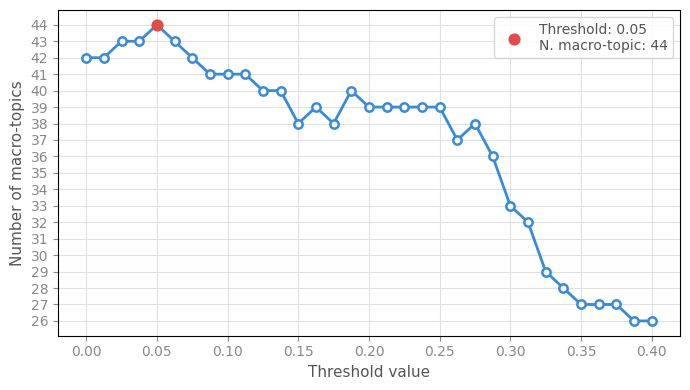

In [30]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

max_idx = np.argmax(community_list)

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
})

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(threshold_list, community_list,
        color='#378ADD', linewidth=2, marker='o',
        markersize=6, markerfacecolor='white',
        markeredgecolor='#378ADD', markeredgewidth=1.8)

ax.scatter(threshold_list[max_idx], community_list[max_idx],
           color='#E24B4A', s=60, zorder=4, label=f'Threshold: {threshold_list[max_idx]} \nN. macro-topic: {community_list[max_idx]}')


ax.set_xlabel('Threshold value', color='#555', fontsize=11)
ax.set_ylabel('Number of macro-topics', color='#555', fontsize=11)
ax.tick_params(colors='#888', labelsize=10)
ax.set_yticks(range(min(community_list), max(community_list) + 1))
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.legend(fontsize=10,labelcolor='#555')

plt.grid(True, color='#e0e0e0', linewidth=0.8)
plt.tight_layout()
plt.show()

# Save the figure

dpi = 300

fig.savefig(
    f'./figures/graph_creation_figures/threshold_selection_{dpi}_dpi.png',
    dpi = dpi,
    bbox_inches='tight'
)

### Edge filtering

- Filter all the edges that don't have bidirectional linkage
- Filter all the edges that have a Topic Closeness less than 0.05
- Filter all the edges with less than 5 match

In [50]:
enriched_edges = edges.merge(nodes,how='inner',left_on='Model 1 Label',right_on='Topic Label')

In [51]:
enriched_edges['N_Match'] = enriched_edges['Topic Closeness']  * enriched_edges['Degree']

In [ ]:
enriched_edges = enriched_edges[ enriched_edges['N_Match'] > MIN_ABS_MATCH ]

In [ ]:
#5th percentile threshold
PRIMARY_COMMUNITY_THRESHOLD = 0.05

#1st percentile threshold
#PRIMARY_COMMUNITY_THRESHOLD = 0.1125

In [54]:
filtered_topics_1 = []
filtered_topics_2 = []
closeness = []

for _, edge in enriched_edges.iterrows():

    topic1 = edge['Model 1 Label']
    topic2 = edge['Model 2 Label']
    c = edge['Topic Closeness']

    if c <= PRIMARY_COMMUNITY_THRESHOLD:
        continue

    bidirection = enriched_edges[
        (enriched_edges['Model 1 Label'] == topic2) &
        (enriched_edges['Model 2 Label'] == topic1) &
        (enriched_edges['Topic Closeness'] > PRIMARY_COMMUNITY_THRESHOLD)
    ]

    if not bidirection.empty:

        filtered_topics_1.append(topic1)
        filtered_topics_2.append(topic2)
        closeness.append(c)

In [55]:
filtered_edges = pd.DataFrame({'Model 1 Label': filtered_topics_1,
                        'Model 2 Label': filtered_topics_2,
                        'Topic Closeness':closeness})

### Graph creation

In [56]:
G = nx.DiGraph(description='Connected components') 

for _, node in nodes.iterrows():
    G.add_node(
    node['Topic Label'],
    degree=node['Degree'],
    model=node['Model']
)

for _, edge in filtered_edges.iterrows():
    G.add_edge(
    edge['Model 1 Label'],
    edge['Model 2 Label'],
    weight=edge['Topic Closeness']
)

### Graph transformation - Undirect to Direct graph

We need to transform directed graph into undirected graph.
To do it, we need to decide how combine the weights of the two edges.

The options are:
- Min
- Harmonic mean
- Fuzzy Union

To be more conservative, we adopt the min between two weights.

In [57]:
dir_weights = {}

for u, v, data in G.edges(data=True):
    w = data["weight"]
    dir_weights[(u, v)] = w

In [58]:
def harmonic_mean(a, b, eps=1e-9):
    return 2*a*b/(a+b+eps)

In [59]:
def fuzzy_union(a,b):
    return a + b - (a * b)

In [60]:
G_und = nx.Graph()

for (u, v), w_uv in dir_weights.items():

    if (v, u) in dir_weights:
        w_vu = dir_weights[(v, u)]

        w = min(w_uv, w_vu)
        #w = harmonic_mean(w_uv, w_vu)
        #w = fuzzy_union(w_uv, w_vu)

        if not G_und.has_edge(u, v):
            G_und.add_edge(u, v, weight=w)


### Community algorithm execution - First phase - Primary macro-structure identification

We adopt the Leiden algorithm to build a primary community structure.

See more about it on https://medium.com/@swapnil.agashe456/leiden-clustering-for-community-detection-a-step-by-step-guide-with-python-implementation-c883933a1430

In [61]:
nodes = list(G_und.nodes())
G_ig = ig.Graph.from_networkx(G_und)
G_ig.vs["name"] = nodes

In [62]:
partition = leidenalg.find_partition(
    G_ig,
    leidenalg.ModularityVertexPartition,
    weights="weight",
    n_iterations=-1
)

In [63]:
clusters = partition.membership

In [64]:
node_to_cluster = {
    v["name"]: clusters[i]
    for i, v in enumerate(G_ig.vs)
}

### Inspect macro-topic composition

In [65]:
clusters = defaultdict(list)

for node, comm in node_to_cluster.items():
    clusters[comm].append(node)

for c, nodes in clusters.items():
    print(f"Cluster {c}:")
    print(", ".join(nodes))
    print()

Cluster 13:
Multidrug-Resistant Tuberculosis Management, Multidrug-Resistant Tuberculosis Outbreaks, Mycobacterium tuberculosis genetic diversity

Cluster 6:
Zoonotic Spillover and Wildlife Health, Environmental Drivers of Zoonotic Spillover, Global Health Emergency Preparedness, Pandemic Preparedness and Response Planning, Wastewater Based Outbreak Surveillance

Cluster 4:
Dengue Virus Epidemiology and Control, Aedes aegypti Vector-borne Diseases, West Nile virus transmission, Mosquito-borne Infectious Diseases, Climate-sensitive Infectious Disease Risks, Vector-Borne Disease Transmission

Cluster 8:
Genetic Control of Aedes Mosquitoes, Zika and other arboviral infections, Zika and Dengue Outbreaks, Zika Virus Outbreak and Fetal Impact

Cluster 2:
Antimicrobial Stewardship and Surveillance, Antibiotic Resistance and Superbugs, Antibiotic-Resistant Bacterial Strains, Antibiotic Resistance in Wastewater, Veterinary Antimicrobial Use and Resistance, Antibiotic Resistance and Stewardship,

In [66]:
label_name = []
cluster_number = []
for k,v in node_to_cluster.items():
    label_name.append(k)
    cluster_number.append(v)


In [67]:
print(f"Number of communities: {sorted(cluster_number)[-1]+1}")

Number of communities: 48


In [68]:
leiden_cluster = pd.DataFrame({'Topic Label':label_name,
              'Cluster': cluster_number})

In [ ]:
# Mark the primary macro-structure with insertion run equal to 0
leiden_cluster['Insertion_run'] = 0

### Sub-communities [ Human-in-the-loop ] - Only if necessary

In [ ]:
import pandas as pd
edges = pd.read_parquet('edges_0_0_5.parquet')
nodes = pd.read_parquet('nodes_0_0_5.parquet')

In [44]:
clusters = leiden_cluster['Cluster'].sort_values().unique()

In [ ]:
# macro-topics to be splitted with another community detection step
clusters_to_interate = [0,8]

for cluster in clusters_to_interate:
    
    topics_in_cluster = leiden_cluster[ leiden_cluster.Cluster == cluster ]['Topic Label'].to_list()
    topic_in_cluster_edges = edges[ ( edges['Model 1 Label'].isin(topics_in_cluster) & edges['Model 2 Label'].isin(topics_in_cluster)) ]
    topic_in_cluster_nodes = nodes[ nodes['Topic Label'].isin(topics_in_cluster) ]


    G_second_round = nx.DiGraph(description='Connected components') 

    for _, node in topic_in_cluster_nodes.iterrows():
        G_second_round.add_node(
        node['Topic Label'],
        degree=node['Degree'],
        model=node['Model']
    )

    for _, edge in topic_in_cluster_edges.iterrows():
        G_second_round.add_edge(
        edge['Model 1 Label'],
        edge['Model 2 Label'],
        weight=edge['Topic Closeness']
    )
        
    dir_weights = {}

    for u, v, data in G_second_round.edges(data=True):
        w = data["weight"]
        dir_weights[(u, v)] = w

    G_und_second = nx.Graph()

    for (u, v), w_uv in dir_weights.items():

        if (v, u) in dir_weights:
            w_vu = dir_weights[(v, u)]

            w = min(w_uv, w_vu)
            #w = harmonic_mean(w_uv, w_vu)
            #w = fuzzy_union(w_uv, w_vu)

            if not G_und_second.has_edge(u, v):
                G_und_second.add_edge(u, v, weight=w)
    
    nodes_second = list(G_und_second.nodes())
    G_ig_second = ig.Graph.from_networkx(G_und_second)
    G_ig_second.vs["name"] = nodes_second

    partition_second = leidenalg.find_partition(
    G_ig_second,
    leidenalg.ModularityVertexPartition,
    weights="weight",
    n_iterations=-1
    )
    clusters_second = partition_second.membership
    node_to_cluster_second = {
        v["name"]: clusters_second[i]
        for i, v in enumerate(G_ig_second.vs)
    }
    clusters_second = defaultdict(list)

    for node, comm in node_to_cluster_second.items():
        clusters_second[comm].append(node)
    
    last_cluster = leiden_cluster.Cluster.max().item() 

    label_name = []
    cluster_number = []

    for k,v in node_to_cluster_second.items():
        label_name.append(k)
        cluster_number.append(v+last_cluster+1)

    leiden_cluster_to_add = pd.DataFrame({'Topic Label':label_name,
              'Cluster': cluster_number},
              )
    
    leiden_cluster_to_add['Insertion_run'] = 0

    leiden_cluster = leiden_cluster[ leiden_cluster.Cluster != cluster ]

    leiden_cluster = pd.concat([leiden_cluster,leiden_cluster_to_add])

save the new macro-structure

In [28]:
leiden_cluster.sort_values(by='Cluster').to_csv(f'community_enrichment_subcom.csv',sep='ç',encoding='utf-8')

### Second phase - Macro topic enrichment

Now, we enrich the primary community structure using the similarity between excluded topics and cluster members.

In [127]:
# The threshold that permit to decide when stop the insertion of unclustered topics
MEAN_CLOSENESS_THRESHOLD = 0.1
TOPICS_TO_ADD_EACH_RUN = 1

leiden_cluster.sort_values(by='Cluster').to_csv(f'primary_community_structure_0_0_1.csv',sep='ç',encoding='utf-8')
print('Primary community structure saved')

Primary community structure saved


In [128]:
model_cols = ['scopus','the_guardian','science_news']

In [ ]:
## Enrichment loop
i = 1

while True:
    # Add the cluster size to the dataframe

    leiden_cluster['Model'] = leiden_cluster['Topic Label'].apply(lambda x: G.nodes[x]['model'].lower())
    df_pivot = (
    leiden_cluster
      .pivot_table(index="Cluster", columns="Model", aggfunc="size", fill_value=0)
      .reset_index()
    )

    leiden_cluster = leiden_cluster.merge(df_pivot, on="Cluster", how="left").fillna(0)

    cluster_to_uncluster = edges[ ( edges['Model 1 Label'].isin(leiden_cluster['Topic Label']) ) & ( ~ edges['Model 2 Label'].isin(leiden_cluster['Topic Label']) ) ]
    uncluster_to_cluster = edges[ ( ~ edges['Model 1 Label'].isin(leiden_cluster['Topic Label']) ) & (  edges['Model 2 Label'].isin(leiden_cluster['Topic Label']) ) ]

    bidirectional_edges = pd.merge(
        cluster_to_uncluster,
        uncluster_to_cluster,
        left_on=["Model 1 Label", "Model 2 Label"],
        right_on=["Model 2 Label", "Model 1 Label"],
        how="inner"
    )
    
    bidirectional_edges['Topic Closeness'] = bidirectional_edges['Topic Closeness_x'] + bidirectional_edges['Topic Closeness_y'] - ( bidirectional_edges['Topic Closeness_x'] * bidirectional_edges['Topic Closeness_y'] )
    
    bidirectional_edges = bidirectional_edges.rename(columns={
        'Model 1 Label_y' : 'Model 1 Label',
        'Model 2 Label_y' : 'Model 2 Label',
    }).drop(columns=['Model 1 Label_x','Model 2 Label_x','Topic Closeness_y','Topic Closeness_x'])

    unclustered_not_bidirectional = uncluster_to_cluster.merge(bidirectional_edges,on=['Model 1 Label','Model 2 Label'],how='left')

    unclustered_not_bidirectional = unclustered_not_bidirectional[ unclustered_not_bidirectional['Topic Closeness_y'].isna()].drop(columns=['Topic Closeness_y']).rename(columns={'Topic Closeness_x':'Topic Closeness'})

    unclustered_topics = pd.concat([unclustered_not_bidirectional,bidirectional_edges])

    unclustered_topics_with_closeness = unclustered_topics.merge(leiden_cluster,how='left',left_on='Model 2 Label',right_on='Topic Label')

    unclustered_topics_with_closeness['Model'] = unclustered_topics_with_closeness['Model 1 Label'].apply(lambda x: G.nodes[x]['model'].lower())


    unclustered_topics_with_closeness['Cluster size'] = (
        unclustered_topics_with_closeness[model_cols].sum(axis=1) -
        unclustered_topics_with_closeness.apply(lambda x: x[x['Model']], axis=1)
    )

    # For each unclustered topic, sum the best 3 edges with the cluster members
    k = 2
    
    unclustered_topics_with_closeness['k'] = (
    np.maximum(
        k,
        np.sqrt(unclustered_topics_with_closeness['Cluster size'])
    )
    .pipe(np.ceil)
    .astype(int)
    )

    def top_k_per_group(g):
        k = g['k'].iloc[0]  
        return g.head(k)

    top_k_closeness = (
        unclustered_topics_with_closeness
        .groupby(['Model 1 Label','Cluster','Cluster size','k'], group_keys=False)
        .apply(top_k_per_group)
        .groupby(['Model 1 Label','Cluster','Cluster size','k'])['Topic Closeness']
        .sum()
        .reset_index(name='Topic_Closeness_Sum')
    )

    # Compute the mean by k (even if there aren't enough connections)
    top_k_closeness = top_k_closeness.reset_index()
    
    top_k_closeness['Topic Closeness Mean'] = top_k_closeness['Topic_Closeness_Sum'] / top_k_closeness['k']

    unclustered_topics_with_closeness_aggregated = top_k_closeness.copy()

    # Aggregate and select the best cluster that has the best mean score
    the_best_unclustered_topics = unclustered_topics_with_closeness_aggregated.loc[ 
    unclustered_topics_with_closeness_aggregated.groupby(['Model 1 Label'])["Topic Closeness Mean"].idxmax()
    ]
    
    the_best_unclustered_topics = the_best_unclustered_topics.astype({'Cluster':"int64","Cluster size":"int64"})

    # Select the best 10 uncluster topic and add to appropriate clusters
    added_topics = the_best_unclustered_topics[ the_best_unclustered_topics['Topic Closeness Mean'] >= MEAN_CLOSENESS_THRESHOLD ].sort_values(by='Topic Closeness Mean',ascending=False)[['Model 1 Label','Cluster','Cluster size']]
    added_topics = added_topics.rename(columns={'Model 1 Label':'Topic Label'})
    added_topics['Insertion_run'] = i
    leiden_cluster = pd.concat([leiden_cluster,added_topics.head(TOPICS_TO_ADD_EACH_RUN)])

    leiden_cluster = leiden_cluster.drop(columns=['Cluster size','Model']+model_cols)

    # Save the run outcome
    if len(added_topics) > 0:
        print(f'Run {i}: {len(added_topics.head(TOPICS_TO_ADD_EACH_RUN))} added')
        i += 1
    else:
        print(f'All the unclustered topics above the {MEAN_CLOSENESS_THRESHOLD} threshold were assigned to the clusters')
        print('Saving results')
        leiden_cluster.sort_values(by='Cluster').to_csv(f'community_enrichment_results_0_0_5.csv',sep='ç',encoding='utf-8')
        break

Run 1: 1 added
Run 2: 1 added
Run 3: 1 added
Run 4: 1 added
Run 5: 1 added
Run 6: 1 added
Run 7: 1 added
Run 8: 1 added
Run 9: 1 added
Run 10: 1 added
Run 11: 1 added
Run 12: 1 added
Run 13: 1 added
Run 14: 1 added
Run 15: 1 added
Run 16: 1 added
Run 17: 1 added
Run 18: 1 added
Run 19: 1 added
Run 20: 1 added
Run 21: 1 added
Run 22: 1 added
Run 23: 1 added
Run 24: 1 added
Run 25: 1 added
Run 26: 1 added
Run 27: 1 added
Run 28: 1 added
Run 29: 1 added
Run 30: 1 added
Run 31: 1 added
Run 32: 1 added
Run 33: 1 added
Run 34: 1 added
Run 35: 1 added
Run 36: 1 added
Run 37: 1 added
Run 38: 1 added
Run 39: 1 added
Run 40: 1 added
Run 41: 1 added
Run 42: 1 added
Run 43: 1 added
Run 44: 1 added
Run 45: 1 added
Run 46: 1 added
Run 47: 1 added
Run 48: 1 added
Run 49: 1 added
Run 50: 1 added
Run 51: 1 added
Run 52: 1 added
Run 53: 1 added
Run 54: 1 added
Run 55: 1 added
Run 56: 1 added
Run 57: 1 added
Run 58: 1 added
Run 59: 1 added
Run 60: 1 added
Run 61: 1 added
Run 62: 1 added
Run 63: 1 added
R

## Cluster Label Assignment

### Qwen3 Model

In [69]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

In [70]:
model_name ="Qwen/Qwen3-8B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto"
)

Loading checkpoint shards: 100%|██████████| 5/5 [00:04<00:00,  1.03it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


In [71]:
def evaluate_topic_assignment(keywords_list):
    messages = [
        {
            "role": "user",
            "content": (
                "Create a short topic cluster label from the topic labels below.\n"
                "Return ONLY the label as a short noun phrase (3–6 words).\n"
                
                "Topic Label:\n"
                f"{'\n'.join(f'- {key}' for key in keywords_list)}\n\n"
            )
        }
    ]

    print(messages)


    testo = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
    )
    model_inputs = tokenizer([testo],
                              return_tensors="pt",
                              truncation=True,
                              max_length=2048).to(model.device)
    with torch.inference_mode():
        generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=24,
        do_sample = False,
        temperature = 0.0,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(generated_ids[0][len(model_inputs.input_ids[0]):],
                            skip_special_tokens=True)

    return text.strip().splitlines()[0].lstrip("-• ").strip()


In [72]:
n_clusters = leiden_cluster['Cluster'].unique()

In [ ]:
label_dict = { i:None for i in n_clusters }

for i in n_clusters:
    labels = leiden_cluster[ leiden_cluster['Cluster'] == i ]['Topic Label'].to_list()
    cluster_label=evaluate_topic_assignment(labels)
    print(cluster_label)
    label_dict[i] = cluster_label


### OpenAI model

In [91]:
import json
import time
from openai import OpenAI

client = OpenAI()

BULK_SCHEMA = {
    "type": "json_schema",
    "name": "topic_labels",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "label": {"type": "string",
                    "description": "Short noun phrase cluster label (3–6 words)."
            }
        },
        "required": ["label"],
        "additionalProperties": False
        }
}

#"Do not add information not implied by the keywords.\n"

def evaluate_topic_assignment(
    keywords_list: list,
    model: str = "gpt-5-mini",
    max_retries: int = 3,
    sleep_between_retries: float = 0.8,
    ):

        messages = [{
            "role" : "system",
            "content" : ( "You are a journalist.\n"
                            "Your task is to infer the underlying concept shared by a list of topics and express it as a concise, informative noun-phrase label.\n"
                            "You must abstract from individual topics to the latent cluster they collectively represent.\n"
                            "Do not explain your reasoning.\n"
                            "Return only the final label, following the specified format.\n"
                            "The noun-phrase label must have from 3 to 5 words"
                        )
                    },
                    {
            "role": "user",
            "content": (
                "Create ONE short noun-phrase label that best connects the topic labels."
                f"{'\n'.join(f'- {key}' for key in keywords_list)}"
            )
        }]
        
        attempt = 0
        request_ok = False

        while (request_ok == False) & (attempt < max_retries):
            try:
                resp = client.responses.parse(
                    model=model,
                    input=messages,
                    text={"format": BULK_SCHEMA},
                )

                if resp.output_text != None:
                    data = json.loads(resp.output_text)
                    result = data["label"]
                    request_ok = True       
                
            except Exception as e:
                attempt += 1
                print(f'Request failed for the following reason:{e}')
                time.sleep(sleep_between_retries)

        return result

In [92]:
label_dict_open = { i:None for i in n_clusters }

for i in n_clusters:
    labels = leiden_cluster[ leiden_cluster['Cluster'] == i ]['Topic Label'].to_list()
    cluster_label=evaluate_topic_assignment(labels)
    print(f'{i}) {cluster_label}')
    label_dict_open[i] = cluster_label


45) Vaccine-Induced Immunity and Outcomes
44) Vaccine and Immunotherapy Development
46) Global COVID-19 Pandemic Responses
47) Coronavirus Pandemic Political Response
49) West African Ebola Response
48) Bat-Borne Zoonotic Virus Emergence
50) One Health Antimicrobial Resistance
52) Strategies Against Antibiotic Resistance
53) Phage-Influenced Microbiome Ecology
51) Livestock Antimicrobial Resistance
54) Zoonotic Avian Influenza Evolution
55) Swine Origin H1N1 Pandemic
57) Zoonotic Spillover Risk Surveillance
58) Wastewater Pathogen Surveillance
56) Pandemic Preparedness and Surveillance
59) Respiratory Infection Burden and Complications
60) Pandemic Lockdown Mental Health Impacts
61) COVID-19 Management in Education
62) Mosquito-borne Viral Disease Control
63) Climate-Driven Vector-Borne Diseases
65) Measles Vaccination and Elimination
64) Vaccination Access and Uptake
67) Engineered Microbial and Phage Therapeutics
66) Genomic Medicine and Microbial Evolution
69) HIV Treatment and Prev

In [75]:
leiden_cluster['Cluster Label'] = leiden_cluster['Cluster'].apply(lambda x: label_dict[x])

### Save the results in parquet file

In [76]:
leiden_cluster['Model'] = leiden_cluster['Topic Label'].apply(lambda x: G.nodes[x]['model'].lower())

In [ ]:
leiden_cluster.to_parquet('community_detection_results_4B_0_0_5.parquet')

## Draw communities

In [ ]:
edges = pd.read_parquet('edges_0_0_5.parquet')
nodes = pd.read_parquet('nodes_0_0_5.parquet')

In [66]:
G_display = nx.DiGraph(description='Connected components') 

for _, node in nodes.iterrows():
    G_display.add_node(
    node['Topic Label'],
    degree=node['Degree'],
    model=node['Model']
)

for _, edge in edges.iterrows():
    G_display.add_edge(
    edge['Model 1 Label'],
    edge['Model 2 Label'],
    weight=edge['Topic Closeness']
)

In [ ]:
leiden_cluster = pd.read_csv('community_enrichment_results_0_0_5.csv',sep='ç',encoding='utf-8')

/tmp/ipykernel_363446/1747517924.py:1: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  leiden_cluster = pd.read_csv('community_enrichment_results_pre.csv',sep='ç',encoding='utf-8')


In [69]:
cluster_dict = leiden_cluster.set_index("Topic Label")['Cluster'].to_dict()

In [70]:
for node in G_display.nodes():
    G_display.nodes[node]['cluster'] = cluster_dict.get(node,-1)

In [71]:
insertion_dict = leiden_cluster.set_index("Topic Label")['Insertion_run'].to_dict()

In [72]:
for node in G_display.nodes():
    G_display.nodes[node]['position'] = insertion_dict.get(node,-1)

In [73]:
import matplotlib as mpl
cmap = mpl.pyplot.cm.tab20

for node in G_display.nodes():
    cluster = G_display.nodes[node].get("cluster",-1)
    if cluster == -1:
        G_display.nodes[node]['color'] = 'black'
    else:
        G_display.nodes[node]['color'] = mpl.colors.to_hex(cmap(cluster % 20))
    

In [ ]:
import networkx as nx
from pyvis.network import Network


def scale(v, vmin, vmax, out_min, out_max):
    """Scala un valore da un range a un altro."""
    if vmax == vmin:
        return (out_min + out_max) / 2
    return out_min + (v - vmin) * (out_max - out_min) / (vmax - vmin)


def export_graph_to_html(
    G, 
    filename="graph.html",
    min_weight=0.0,
    hide_isolates=True,
    height="800px",
    width="100%",
    physics_enabled=True,
    show_buttons=True,
    filter_cluster=None,
    consider_outlier=False,
    size_threshold=-1,
    only_cluster_connection=False
):
    """
    Esporta un grafo NetworkX in un file HTML interattivo standalone.
    
    Parametri:
    ----------
    G : networkx.Graph
        Il grafo da esportare
    filename : str
        Nome del file HTML di output (default: "graph.html")
    min_weight : float
        Soglia minima per mostrare gli archi (default: 0.0)
    hide_isolates : bool
        Se True, nasconde i nodi senza archi dopo il filtro (default: True)
    height : str
        Altezza del grafo (default: "800px")
    width : str
        Larghezza del grafo (default: "100%")
    physics_enabled : bool
        Se True, abilita la simulazione fisica (default: True)
    show_buttons : bool
        Se True, mostra i controlli interattivi (default: True)
    
    Returns:
    --------
    dict : Statistiche del grafo esportato
    """

    icon_map = {"Scopus": "●", "Science_News": "▲", "The_Guardian": "✖"}

    if consider_outlier and filter_cluster:
        filter_cluster.append(-1)

    # 1) FILTRA GLI ARCHI in base al peso minimo e al cluster
    edges_kept = []
    for u, v, a in G.edges(data=True):
        # Cluster isolation
        if only_cluster_connection:
            if ( G.nodes[u].get('cluster',-1) == G.nodes[v].get('cluster',-1) ) :
                continue

        if filter_cluster:
            if ( G.nodes[u].get('cluster',-1) not in filter_cluster ) | ( G.nodes[v].get('cluster',-1) not in filter_cluster ) :
                continue
            if (len(filter_cluster) > 1) and  (  G.nodes[u].get('cluster',-1) == -1 & G.nodes[v].get('cluster',-1) == -1  ):
                continue
        if size_threshold != -1:
            if ( G.nodes[u].get('degree',0) <= size_threshold ) or (G.nodes[v].get('degree',0) <= size_threshold ):
                continue

        w = float(a.get("weight", 0.0))
        if w >= min_weight:
            edges_kept.append((u, v, w))
    
    # 2) DETERMINA I NODI DA MANTENERE
    if hide_isolates:
        # Solo nodi che hanno almeno un arco
        nodes_kept = set()
        for u, v, _ in edges_kept:
            nodes_kept.add(u)
            nodes_kept.add(v)
    else:
        # Tutti i nodi del grafo
        nodes_kept = set(G.nodes())
    
    # 3) CREA IL SUBGRAFO
    G_sub = G.subgraph(nodes_kept).copy()
    
    # 4) CALCOLA RANGE PER SCALING
    if G_sub.number_of_nodes() > 0:
        deg_vals = [G_sub.nodes[n].get("degree", G_sub.degree(n)) for n in G_sub.nodes()]
        dmin, dmax = min(deg_vals), max(deg_vals)
    else:
        dmin, dmax = 0, 1
    
    if edges_kept:
        w_vals = [w for _, _, w in edges_kept]
        wmin, wmax = min(w_vals), max(w_vals)
    else:
        wmin, wmax = 0, 1
    
    # 5) CREA LA RETE PYVIS
    net = Network(
        height=height,
        width=width,
        directed=True,
        notebook=False,
        cdn_resources='remote',
        bgcolor='#ffffff',
        font_color='black'
    )
            
    # Configura la fisica direttamente nelle opzioni della rete
    if physics_enabled:
        net.barnes_hut(
            gravity=-3000,  # Ridotto per meno attrazione al centro
            central_gravity=0.1,  # Ridotto per permettere la separazione
            spring_length=250,  # Aumentato per più spazio
            spring_strength=0.01,  # Ridotto per meno rigidità
            damping=0.15,  # Aumentato per stabilizzare prima
            overlap=0.2  # Aumentato per evitare sovrapposizioni
        )
    
    # 7) AGGIUNGI I NODI CON POSIZIONI
    for n in G_sub.nodes():
        a = G_sub.nodes[n]
        degree = a.get("degree", G_sub.degree(n))
        
        # Scala la dimensione del nodo in base al grado
        size = scale(float(degree), float(dmin), float(dmax), 15, 50)
        
        color = a.get("color","black")
        source_model = a.get("model","UNKNOWN")
        position = a.get("position",-1)
        
        # Crea il titolo (tooltip) con informazioni dettagliate
        title = f"Label: {n}\nModel: {source_model}\nN.Articles: {degree}\nPosition:{position}"
        #title = f"<b>{n}</b><br>Modello: {source_model}<br>Grado: {degree}"

        
        net.add_node(
            n,
            label=f"{icon_map[source_model]} {n}",
            value=size, 
            color={
                "background": color,
                "border": "black"
            },
            title=title,
            physics=physics_enabled  # Se physics=False, la posizione è fissa
        )
    
    # 8) AGGIUNGI GLI ARCHI
    for u, v, w in edges_kept:
        if u not in G_sub or v not in G_sub:
            continue
        
        # Scala lo spessore dell'arco in base al peso
        width = scale(float(w), float(wmin), float(wmax), 1.0, 8.0)
        
        source_model_1 = G_sub.nodes[u].get("model","UNKNOWN")
        source_model_2 = G_sub.nodes[v].get("model","UNKNOWN")

        # Tooltip per l'arco
        title = f"{u} → {v}\n{source_model_1} → {source_model_2}\nWeight: {w:.3f}\n"
        
        color_edge = G_sub.nodes[u].get("color","black")

        net.add_edge(
            u, v,
            value=width,
            title=title,
            color=color_edge,
            shadow={
            "enabled": True,
            "color": "rgba(255,255,255,0.9)",  # halo chiaro
            "size": 6,
            "x": 0,
            "y": 0
            },
            weight=w,
            smooth=True,
            arrowStrikethrough=False
        )
    
    # 9) MOSTRA/NASCONDI PULSANTI DI CONTROLLO
    if show_buttons:
        try:
            net.show_buttons(filter_=['physics'])
        except:
            pass 
    
    if not physics_enabled:
        net.toggle_physics(False)
    
    # 10) SALVA IL FILE
    net.save_graph(filename)

Graph creation

In [ ]:
cluster_df = pd.read_parquet('community_detection_results_4B_final.parquet')
cluster_dict = cluster_df.set_index('Cluster')['Cluster Label'].to_dict()

export_graph_to_html(
                        G_display,
                        #filename=f"Graph_clusters/{i}_{cluster_dict[i]}_out_0_5.html",
                        filename=f"Graph_clusters/AMR_vs_HAI.html",
                        # Filter connections based on edges weights
                        min_weight=0.0,
                        # Hide not connected nodes
                        hide_isolates=True,
                        # Display settings
                        show_buttons=False,
                        # Filter using macro-topic 
                        filter_cluster= [2,13],
                        # Show unassigned nodes but connected with assigned ones
                        consider_outlier=False,
                        # Filter using node dimension
                        size_threshold = 0.0,
                        # Display only connection inter macro-topic
                        only_cluster_connection = False
)

Iterative graph creation

In [ ]:
for i in cluster_dict.keys():
    export_graph_to_html(
                            G_display,
                            filename=f"Graph_clusters/{i}_{cluster_dict[i]}_out_0_5.html",
                            # Filter connections based on edges weights
                            min_weight=0.0,
                            # Hide not connected nodes
                            hide_isolates=True,
                            # Display settings
                            show_buttons=False,
                            # Filter using macro-topic 
                            filter_cluster= [i],
                            # Show unassigned nodes but connected with assigned ones
                            consider_outlier=False,
                            # Filter using node dimension
                            size_threshold = 0.0,
                            # Display only connection inter macro-topic
                            only_cluster_connection = False
    )

## Meta inter-clusters analysis 

In [42]:
leiden_cluster_copy = pd.read_parquet('community_detection_results_4B_0_0_5.parquet')

In [43]:
cluster_infos = edges.merge(leiden_cluster_copy.drop(columns=['Model']).rename(columns={'Topic Label':'Model 1 Label',
                                                                           'Cluster':'Cluster 1',
                                                                           'Cluster Label': 'Cluster Label 1'}),on='Model 1 Label')

In [44]:
cluster_infos = cluster_infos.merge(leiden_cluster_copy.drop(columns=['Model']).rename(columns={'Topic Label':'Model 2 Label',
                                                                           'Cluster':'Cluster 2',
                                                                           'Cluster Label': 'Cluster Label 2'}),on='Model 2 Label')

In [ ]:
cluster_infos_filtered = cluster_infos[ cluster_infos['Topic Closeness'] > 0.1]

In [46]:
cluster_infos_aggr = cluster_infos_filtered.groupby(['Cluster Label 1','Cluster Label 2'])['Topic Closeness'].mean().reset_index()
cluster_infos_aggr = cluster_infos_aggr[ cluster_infos_aggr['Cluster Label 1'] != cluster_infos_aggr['Cluster Label 2']]

In [47]:
cluster_infos_aggr['Log Topic Closeness'] = cluster_infos_aggr['Topic Closeness'].apply(lambda x: - np.log(x))

In [48]:
unique_nodes = list(set(
    cluster_infos_aggr["Cluster Label 1"].tolist() + cluster_infos_aggr["Cluster Label 2"].tolist()
))

G_cluster = nx.DiGraph()

import matplotlib as mpl
cmap = mpl.pyplot.cm.tab20

for idx, i in enumerate(unique_nodes):
    G_cluster.add_node(
        i,
        color=mpl.colors.to_hex(cmap(idx % 20))  # <-- usa idx, non i
    )

for _, edge in cluster_infos_aggr.iterrows():
    G_cluster.add_edge(
        str(edge["Cluster Label 1"]),
        str(edge["Cluster Label 2"]),
        weight=float(edge["Log Topic Closeness"])
    )

In [49]:
import networkx as nx
from pyvis.network import Network


def scale(v, vmin, vmax, out_min, out_max):
    """Scala un valore da un range a un altro."""
    if vmax == vmin:
        return (out_min + out_max) / 2
    return out_min + (v - vmin) * (out_max - out_min) / (vmax - vmin)

def invert_scale(v,out_min,out_max):
    """Inverte la scala"""
    return out_max - v + out_min

def export_graph_to_html(
    G, 
    filename="graph.html",
    min_weight=0.0,
    hide_isolates=True,
    height="800px",
    width="100%",
    physics_enabled=True,
    show_buttons=True,
):
    """
    Esporta un grafo NetworkX in un file HTML interattivo standalone.
    
    Parametri:
    ----------
    G : networkx.Graph
        Il grafo da esportare
    filename : str
        Nome del file HTML di output (default: "graph.html")
    min_weight : float
        Soglia minima per mostrare gli archi (default: 0.0)
    hide_isolates : bool
        Se True, nasconde i nodi senza archi dopo il filtro (default: True)
    height : str
        Altezza del grafo (default: "800px")
    width : str
        Larghezza del grafo (default: "100%")
    physics_enabled : bool
        Se True, abilita la simulazione fisica (default: True)
    show_buttons : bool
        Se True, mostra i controlli interattivi (default: True)
    
    Returns:
    --------
    dict : Statistiche del grafo esportato
    """
    # 1) FILTRA GLI ARCHI in base al peso minimo e al cluster
    edges_kept = []
    for u, v, a in G.edges(data=True):

        w = float(a.get("weight", 0.0))

        color = G.nodes[u]

        if w >= min_weight:
            edges_kept.append((u, v, w))
    
    # 2) DETERMINA I NODI DA MANTENERE
    if hide_isolates:
        # Solo nodi che hanno almeno un arco
        nodes_kept = set()
        for u, v, _ in edges_kept:
            nodes_kept.add(u)
            nodes_kept.add(v)
    else:
        # Tutti i nodi del grafo
        nodes_kept = set(G.nodes())
    
    # 3) CREA IL SUBGRAFO
    G_sub = G.subgraph(nodes_kept).copy()
    
    # 4) CALCOLA RANGE PER SCALING
    if G_sub.number_of_nodes() > 0:
        deg_vals = [G_sub.nodes[n].get("degree", G_sub.degree(n)) for n in G_sub.nodes()]
        dmin, dmax = min(deg_vals), max(deg_vals)
    else:
        dmin, dmax = 0, 1
    
    if edges_kept:
        w_vals = [w for _, _, w in edges_kept]
        wmin, wmax = min(w_vals), max(w_vals)
    else:
        wmin, wmax = 0, 1
    
    # 5) CREA LA RETE PYVIS
    net = Network(
        height=height,
        width=width,
        directed=True,
        notebook=False,
        cdn_resources='remote',
        bgcolor='#ffffff',
        font_color='black'
    )
            
    # Configura la fisica direttamente nelle opzioni della rete
    if physics_enabled:
        net.barnes_hut(
            gravity=-3000,  # Ridotto per meno attrazione al centro
            central_gravity=0.1,  # Ridotto per permettere la separazione
            spring_length=250,  # Aumentato per più spazio
            spring_strength=0.01,  # Ridotto per meno rigidità
            damping=0.15,  # Aumentato per stabilizzare prima
            overlap=0.2  # Aumentato per evitare sovrapposizioni
        )
    
    # 7) AGGIUNGI I NODI CON POSIZIONI
    for n in G_sub.nodes():
        a = G_sub.nodes[n]
        degree = a.get("degree", G_sub.degree(n))
        
        # Scala la dimensione del nodo in base al grado
        size = scale(float(degree), float(dmin), float(dmax), 15, 50)
        
        color = a.get("color","black")
        
        # Crea il titolo (tooltip) con informazioni dettagliate
        title = f"Label: {n}"
        #title = f"<b>{n}</b><br>Modello: {source_model}<br>Grado: {degree}"

        
        net.add_node(
            n,
            value=size, 
            color={
                "background": color,
                "border": "black"
            },
            title=title,
            physics=physics_enabled  # Se physics=False, la posizione è fissa
        )
    
    # 8) AGGIUNGI GLI ARCHI
    for u, v, w in edges_kept:
        if u not in G_sub or v not in G_sub:
            continue
        
        # Scala lo spessore dell'arco in base al peso
        width = scale(float(w), float(wmin), float(wmax), 1.0, 8.0)
        # In questo caso valori + grandi indicano diversità essendo una lunghezza e perciò devo invertire la scala
        width = invert_scale(width,1.0,8.0)

        # Tooltip per l'arco
        title = f"{u} → {v}\nWeight: {w:.3f}\n"
        
        color_edge = G_sub.nodes[u].get("color","black")

        net.add_edge(
            u, v,
            value=width,
            title=title,
            color=color_edge,
            shadow={
            "enabled": True,
            "color": "rgba(255,255,255,0.9)",  # halo chiaro
            "size": 6,
            "x": 0,
            "y": 0
            },
            weight=w,
            smooth=True,
            arrowStrikethrough=False
        )
    
    # 9) MOSTRA/NASCONDI PULSANTI DI CONTROLLO
    if show_buttons:
        try:
            net.show_buttons(filter_=['physics'])
        except:
            pass 
    
    if not physics_enabled:
        net.toggle_physics(False)
    
    # 10) SALVA IL FILE
    net.save_graph(filename)

In [50]:
export_graph_to_html(
        G_cluster,
        filename="meta_cluster_analysis.html",
        min_weight=0.0,
        hide_isolates=False,
        show_buttons=True,
)

### Create svg image with the same position

In [62]:
with open('meta_cluster_analysis.html', "r", encoding="utf-8") as f:
    html = f.read()

export_positions_js = """
<button onclick="downloadPositions()" style="
    position: absolute;
    top: 10px;
    left: 10px;
    z-index: 9999;
">
Download node positions
</button>

<script>
function downloadPositions() {
    network.stopSimulation();
    var positions = network.getPositions();
    var dataStr = "data:text/json;charset=utf-8," + encodeURIComponent(JSON.stringify(positions, null, 2));
    var downloadAnchorNode = document.createElement('a');
    downloadAnchorNode.setAttribute("href", dataStr);
    downloadAnchorNode.setAttribute("download", "node_positions.json");
    document.body.appendChild(downloadAnchorNode);
    downloadAnchorNode.click();
    downloadAnchorNode.remove();
}
</script>
"""

html = html.replace("</body>", export_positions_js + "\n</body>")

with open('meta_cluster_analysis.html', "w", encoding="utf-8") as f:
    f.write(html)

In [58]:
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx

mpl.rcParams["svg.fonttype"] = "none"

def export_svg_with_pyvis_positions(
    G_sub,
    edges_kept,
    positions_json="node_positions.json",
    filename="graph.svg"
):
    with open(positions_json, "r", encoding="utf-8") as f:
        raw_pos = json.load(f)

    pos = {
        n: (raw_pos[str(n)]["x"], -raw_pos[str(n)]["y"])
        for n in G_sub.nodes()
        if str(n) in raw_pos
    }

    fig, ax = plt.subplots(figsize=(16, 12))

    node_colors = [
        G_sub.nodes[n].get("color", "black")
        for n in G_sub.nodes()
    ]

    node_sizes = [
        600
        for n in G_sub.nodes()
    ]

    edge_colors = [
        G_sub.nodes[u].get("color", "black")
        for u, v, w in edges_kept
        if u in G_sub and v in G_sub
    ]

    edge_widths = [
        2
        for u, v, w in edges_kept
        if u in G_sub and v in G_sub
    ]

    edgelist = [
        (u, v)
        for u, v, w in edges_kept
        if u in G_sub and v in G_sub
    ]

    nx.draw_networkx_edges(
        G_sub,
        pos,
        edgelist=edgelist,
        edge_color=edge_colors,
        width=edge_widths,
        arrows=True,
        arrowsize=12,
        alpha=0.8,
        ax=ax
    )

    nx.draw_networkx_nodes(
        G_sub,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=1,
        ax=ax
    )

    nx.draw_networkx_labels(
        G_sub,
        pos,
        font_size=8,
        font_family="DejaVu Sans",
        ax=ax
    )

    ax.set_axis_off()

    fig.savefig(filename, format="svg", bbox_inches="tight")
    plt.close(fig)

In [ ]:
export_svg_with_pyvis_positions()